Data loaded:
- CSV: 20 segments, 45 features
- JSONL: 20 note sequences

=== Basic Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 45 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   segment_id           20 non-null     object 
 1   duration_sec         20 non-null     float64
 2   bpm                  20 non-null     int64  
 3   key                  20 non-null     object 
 4   genre                20 non-null     object 
 5   mood                 20 non-null     object 
 6   time_signature       20 non-null     object 
 7   mfcc_mean_1          20 non-null     float64
 8   mfcc_mean_2          20 non-null     float64
 9   mfcc_mean_3          20 non-null     float64
 10  mfcc_mean_4          20 non-null     float64
 11  mfcc_mean_5          20 non-null     float64
 12  mfcc_mean_6          20 non-null     float64
 13  mfcc_mean_7          20 non-null     float64
 

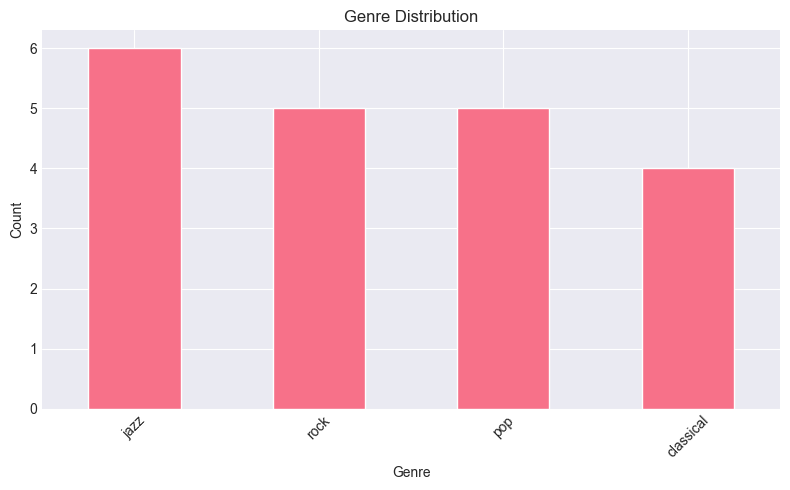


=== Mood Distribution ===
mood
happy        7
energetic    6
calm         4
sad          3
Name: count, dtype: int64


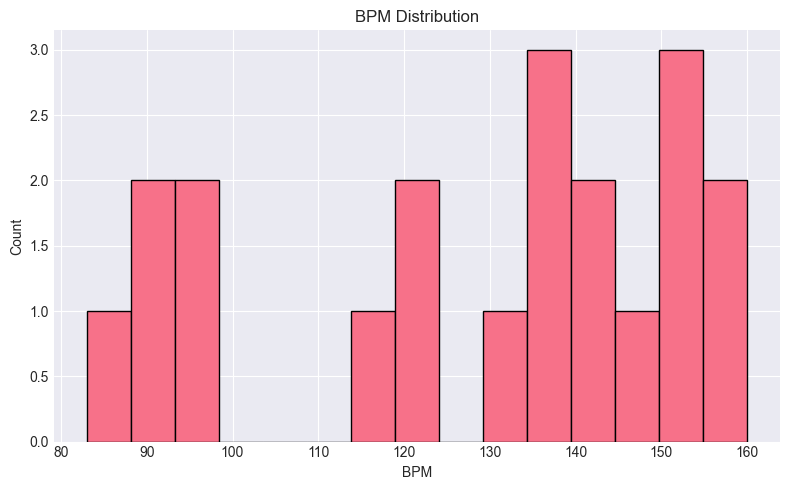

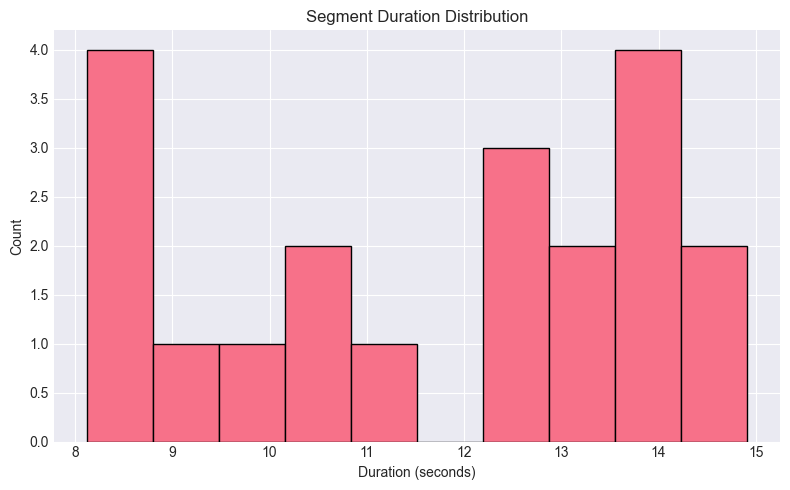


=== Key Distribution ===
key
E_minor    6
D_minor    5
A_minor    4
F_major    2
C_major    2
G_major    1
Name: count, dtype: int64


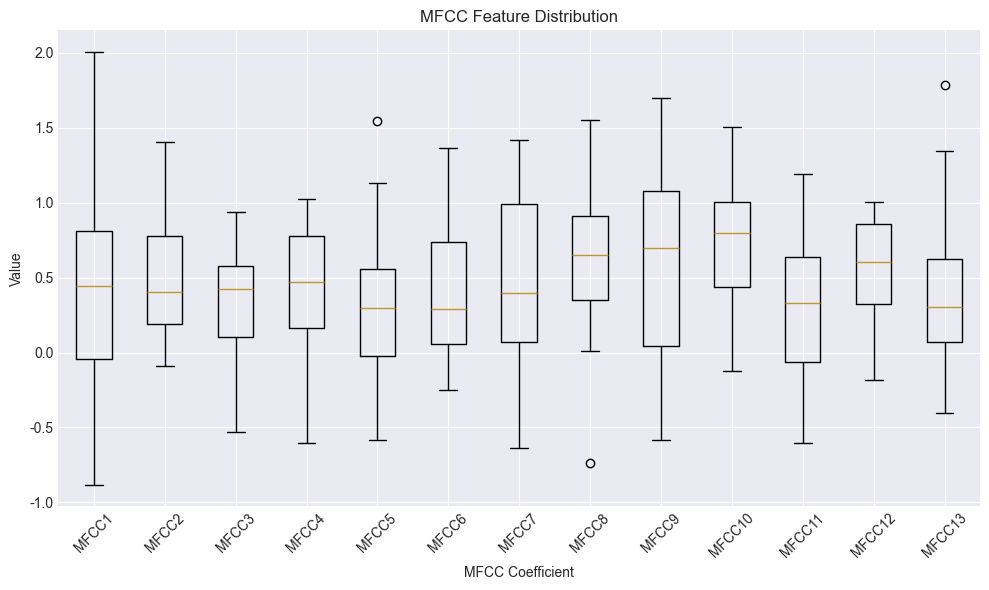


=== Note Sequence Analysis ===


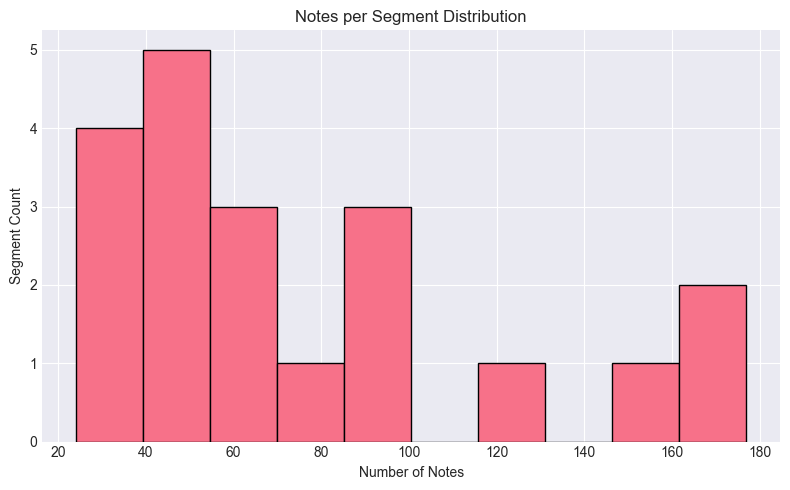

Average notes per segment: 76.0

=== Feature Correlation ===


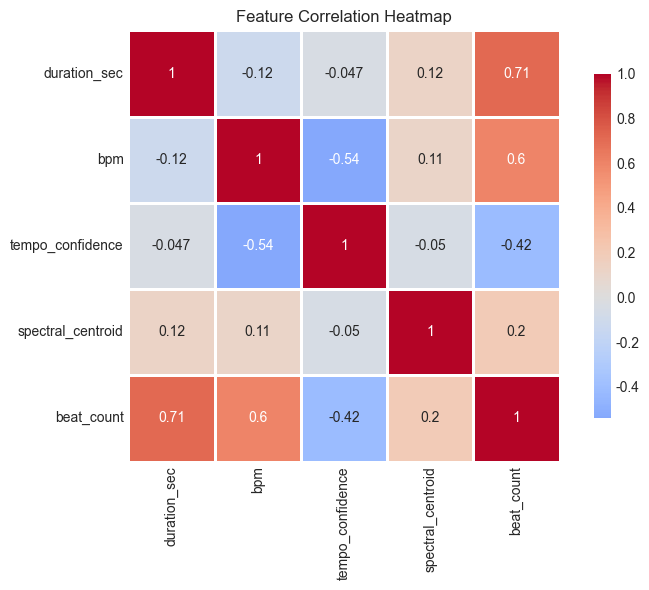


=== Genre Feature Analysis ===
                  bpm  duration_sec  tempo_confidence
genre                                                
classical  146.000000     13.062500          0.783988
jazz       109.166667     10.771667          0.949339
pop        125.400000     12.684000          0.918133
rock       138.600000     10.742000          0.845517

Analysis report saved to: ..\reports\data_analysis_report.json

=== Data Quality Recommendations ===
1. Check data balance across genres
2. Validate note sequence logic
3. Verify feature extraction accuracy
4. Ensure proper train/val/test split

Analysis complete!


In [7]:
# Music Generation Data Analysis Notebook
# Simple and concise English version

# 1. Setup and Data Loading
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load data
data_dir = Path("../data")
df = pd.read_csv(data_dir / "raw/audio_features.csv")

# Load JSONL data
jsonl_data = []
with open(data_dir / "raw/note_sequences.jsonl", "r") as f:
    for line in f:
        jsonl_data.append(json.loads(line.strip()))

print(f"Data loaded:")
print(f"- CSV: {len(df)} segments, {df.shape[1]} features")
print(f"- JSONL: {len(jsonl_data)} note sequences")

# 2. Basic Overview
print("\n=== Basic Overview ===")
print(df.info())
print("\nFirst 3 segments:")
print(df[['segment_id', 'genre', 'mood', 'bpm', 'duration_sec']].head(3))

# 3. Statistical Summary
print("\n=== Statistical Summary ===")
print(df[['duration_sec', 'bpm']].describe())

# 4. Genre Distribution
print("\n=== Genre Distribution ===")
genre_counts = df['genre'].value_counts()
print(genre_counts)

plt.figure(figsize=(8, 5))
genre_counts.plot(kind='bar')
plt.title('Genre Distribution')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/genre_distribution.png', dpi=150)
plt.show()

# 5. Mood Distribution
print("\n=== Mood Distribution ===")
mood_counts = df['mood'].value_counts()
print(mood_counts)

# 6. BPM Analysis
plt.figure(figsize=(8, 5))
plt.hist(df['bpm'], bins=15, edgecolor='black')
plt.title('BPM Distribution')
plt.xlabel('BPM')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/bpm_distribution.png', dpi=150)
plt.show()

# 7. Duration Analysis
plt.figure(figsize=(8, 5))
plt.hist(df['duration_sec'], bins=10, edgecolor='black')
plt.title('Segment Duration Distribution')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/duration_distribution.png', dpi=150)
plt.show()

# 8. Key Distribution
print("\n=== Key Distribution ===")
key_counts = df['key'].value_counts()
print(key_counts)

# 9. MFCC Features Analysis
mfcc_cols = [col for col in df.columns if 'mfcc_mean' in col]
if mfcc_cols:
    mfcc_data = df[mfcc_cols]

    plt.figure(figsize=(10, 6))
    plt.boxplot(mfcc_data.values)
    plt.title('MFCC Feature Distribution')
    plt.xlabel('MFCC Coefficient')
    plt.ylabel('Value')
    plt.xticks(range(1, len(mfcc_cols) + 1), [f'MFCC{i}' for i in range(1, len(mfcc_cols) + 1)], rotation=45)
    plt.tight_layout()
    plt.savefig('../reports/mfcc_distribution.png', dpi=150)
    plt.show()

# 10. Note Sequence Analysis
print("\n=== Note Sequence Analysis ===")
note_counts = [len(item['notes']) for item in jsonl_data]

plt.figure(figsize=(8, 5))
plt.hist(note_counts, bins=10, edgecolor='black')
plt.title('Notes per Segment Distribution')
plt.xlabel('Number of Notes')
plt.ylabel('Segment Count')
plt.tight_layout()
plt.savefig('../reports/note_count_distribution.png', dpi=150)
plt.show()

print(f"Average notes per segment: {np.mean(note_counts):.1f}")

# 11. Feature Correlation
print("\n=== Feature Correlation ===")
selected_features = ['duration_sec', 'bpm', 'tempo_confidence', 'spectral_centroid', 'beat_count']
if all(col in df.columns for col in selected_features):
    corr_matrix = df[selected_features].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Heatmap')
    plt.tight_layout()
    plt.savefig('../reports/feature_correlation.png', dpi=150)
    plt.show()

# 12. Genre vs Features Analysis
print("\n=== Genre Feature Analysis ===")
genre_features = df.groupby('genre')[['bpm', 'duration_sec', 'tempo_confidence']].mean()
print(genre_features)

# 13. Save Analysis Report
analysis_report = {
    "data_overview": {
        "total_segments": len(df),
        "total_features": df.shape[1]
    },
    "genre_distribution": genre_counts.to_dict(),
    "mood_distribution": mood_counts.to_dict(),
    "key_distribution": key_counts.to_dict(),
    "statistics": {
        "duration": {
            "min": float(df['duration_sec'].min()),
            "max": float(df['duration_sec'].max()),
            "mean": float(df['duration_sec'].mean())
        },
        "bpm": {
            "min": int(df['bpm'].min()),
            "max": int(df['bpm'].max()),
            "mean": float(df['bpm'].mean())
        }
    },
    "note_sequence_stats": {
        "avg_notes_per_segment": float(np.mean(note_counts)),
        "min_notes": int(np.min(note_counts)),
        "max_notes": int(np.max(note_counts))
    }
}

report_path = Path("../reports/data_analysis_report.json")
with open(report_path, "w") as f:
    json.dump(analysis_report, f, indent=2)

print(f"\nAnalysis report saved to: {report_path}")

# 14. Data Quality Recommendations
print("\n=== Data Quality Recommendations ===")
print("1. Check data balance across genres")
print("2. Validate note sequence logic")
print("3. Verify feature extraction accuracy")
print("4. Ensure proper train/val/test split")

print("\nAnalysis complete!")